# SAE vs CAZ: Side-by-Side Ablation Comparison

Two methods extract interpretable structure from a transformer's residual stream. They answer different questions:

| | **Sparse Autoencoder (SAE)** | **Concept Assembly Zone (CAZ)** |
|---|---|---|
| **Question** | What features does the model use? | Where and how strongly is *this concept* represented? |
| **What it learns** | ~24K sparse features via reconstruction loss | 1 direction per concept via contrastive pair geometry |
| **Supervision** | Unsupervised (reconstructs activations) | Weakly supervised (needs contrastive pairs) |
| **Layer choice** | Fixed (e.g. layer 8 residual stream) | Adaptive — extracts at the layer of peak geometric separation |
| **Ablation** | Clamp feature activation to zero, decode back | Orthogonal projection removes direction from hidden state |

This notebook runs **both methods on the same model (GPT-2 Small), same concept, same test prompts** and asks:
1. How much do their representations overlap geometrically?
2. When we ablate what each method identifies, how much concept signal is removed?
3. Is the difference driven by **direction quality** or **layer choice**? (2x2 control matrix)
4. What does each method's ablation cost in collateral damage?

**Prerequisites:** The [SAE tutorial](./Mechanistic_Interpretability_LLM_Tutorial.ipynb) and [CAZ companion](./CAZ_Companion_Tutorial.ipynb) cover each method in depth. This notebook assumes familiarity with both.

## 0 — Setup

In [1]:
# Install both toolkits
%pip install -q git+https://github.com/jamesrahenry/Rosetta_Tools.git
%pip install -q sae-lens transformer-lens


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import json
import urllib.request
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

# --- SAE stack ---
from sae_lens import SAE
from transformer_lens import HookedTransformer

# --- CAZ stack ---
from transformers import AutoModel, AutoModelForCausalLM, AutoTokenizer
from rosetta_tools.extraction import extract_layer_activations, extract_contrastive_activations
from rosetta_tools.caz import (
    compute_separation, compute_coherence, compute_velocity,
    compute_layer_metrics, find_caz_regions,
)
from rosetta_tools.ablation import (
    DirectionalAblator, get_transformer_layers,
    compute_dominant_direction, compute_baseline_logits,
    kl_divergence_from_logits,
)
from rosetta_tools.gpu_utils import get_device, get_dtype

device = get_device()
dtype = get_dtype(device)
print(f"Device: {device} | dtype: {dtype}")

/home/jhenry/envs/py312/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda | dtype: torch.bfloat16


### Load GPT-2 Small — both views

We load the model twice: once through TransformerLens (for SAE hooks) and once through HuggingFace transformers (for rosetta_tools). Same weights, different wrappers.

In [3]:
MODEL_NAME = "gpt2"

# --- TransformerLens model (SAE side) ---
tl_model = HookedTransformer.from_pretrained(MODEL_NAME, device=device)
print(f"TransformerLens: {MODEL_NAME} — {tl_model.cfg.n_layers}L, d_model={tl_model.cfg.d_model}")

# --- HuggingFace models (CAZ side) ---
hf_tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
hf_tokenizer.pad_token = hf_tokenizer.eos_token

# Base model for activation extraction
hf_model = AutoModel.from_pretrained(MODEL_NAME, torch_dtype=dtype).to(device)
hf_model.eval()

# CausalLM for logits / text generation
hf_lm = AutoModelForCausalLM.from_pretrained(MODEL_NAME, torch_dtype=dtype).to(device)
hf_lm.eval()

N_LAYERS = hf_model.config.n_layer
D_MODEL = hf_model.config.n_embd
print(f"HuggingFace: {MODEL_NAME} — {N_LAYERS}L, d_model={D_MODEL}")

`torch_dtype` is deprecated! Use `dtype` instead!


Loaded pretrained model gpt2 into HookedTransformer
TransformerLens: gpt2 — 12L, d_model=768
HuggingFace: gpt2 — 12L, d_model=768


### Load SAE dictionary

We use the `gpt2-small-res-jb` SAE trained on layer 8 residual stream pre-activations (Joseph Bloom's dictionary, hosted on HuggingFace via SAELens). 24,576 features learned from the 768-dimensional residual stream — a 32x overcomplete basis.

In [4]:
SAE_LAYER = 8
SAE_RELEASE = "gpt2-small-res-jb"
SAE_ID = f"blocks.{SAE_LAYER}.hook_resid_pre"
HOOK_POINT = SAE_ID  # TransformerLens hook name

print(f"Loading SAE: {SAE_RELEASE} | {SAE_ID}")
result = SAE.from_pretrained(release=SAE_RELEASE, sae_id=SAE_ID, device=device)
sae = result[0] if isinstance(result, tuple) else result

print(f"SAE features: {sae.cfg.d_sae}")
print(f"SAE input dim: {sae.cfg.d_in}")

Loading SAE: gpt2-small-res-jb | blocks.8.hook_resid_pre
SAE features: 24576
SAE input dim: 768


### Load contrastive pairs for the test concept

We'll use **sentiment** — it's a clean, well-separated concept in GPT-2 Small with a clear CAZ peak, and SAE features for positive/negative sentiment are well-documented on Neuronpedia.

In [5]:
CONCEPT = "sentiment"
N_PAIRS = 200  # cap — will use however many are available

GITHUB_RAW = (
    "https://raw.githubusercontent.com/jamesrahenry/Rosetta_Program/main"
    "/datasets/consensus_pairs"
)

url = f"{GITHUB_RAW}/{CONCEPT}_consensus_pairs.jsonl"
print(f"Fetching: {url}")
with urllib.request.urlopen(url) as resp:
    lines = resp.read().decode().strip().split("\n")
records = [json.loads(line) for line in lines]

pair_map = defaultdict(dict)
for r in records:
    pair_map[r["pair_id"]][r["label"]] = r["text"]

pos_texts, neg_texts = [], []
for pid in sorted(pair_map.keys())[:N_PAIRS]:
    p = pair_map[pid]
    if 1 in p and 0 in p:
        pos_texts.append(p[1])
        neg_texts.append(p[0])

print(f"Loaded {len(pos_texts)} contrastive pairs for '{CONCEPT}'")
print(f"  pos example: {pos_texts[0][:80]}...")
print(f"  neg example: {neg_texts[0][:80]}...")

Fetching: https://raw.githubusercontent.com/jamesrahenry/Rosetta_Program/main/datasets/consensus_pairs/sentiment_consensus_pairs.jsonl
Loaded 107 contrastive pairs for 'sentiment'
  pos example: Stepping into Marcello's Trattoria felt like being wrapped in a warm embrace. Th...
  neg example: Walking into Marcello's Trattoria, we were immediately hit by a blast of arctic ...


---
# 1 — Feature Extraction: What Does Each Method Find?

## 1.1 SAE: Sparse feature activations on concept text

In [6]:
# ============================================================
# Run positive and negative texts through the SAE at layer 8
# ============================================================

def get_sae_features(texts, label=""):
    """Encode texts through TransformerLens -> SAE, return per-text max feature activations."""
    tokens = tl_model.to_tokens(texts).to(device)
    with torch.no_grad():
        _, cache = tl_model.run_with_cache(
            tokens, names_filter=lambda name: name == HOOK_POINT
        )
        x = cache[HOOK_POINT]  # [batch, seq, d_model]

    x_flat = x.reshape(-1, x.shape[-1])
    with torch.no_grad():
        z = sae.encode(x_flat)  # [batch*seq, n_features]

    z = z.reshape(x.shape[0], x.shape[1], -1)
    z_max = z.max(dim=1).values  # [batch, n_features] — max across positions

    if label:
        n_active = (z_max > 0).float().sum(dim=1).mean().item()
        print(f"  {label}: {len(texts)} texts, mean {n_active:.0f} active features per text")

    return z_max

BATCH = 16
pos_feats_list, neg_feats_list = [], []
for i in range(0, len(pos_texts), BATCH):
    pos_feats_list.append(get_sae_features(pos_texts[i:i+BATCH], "pos" if i == 0 else ""))
    neg_feats_list.append(get_sae_features(neg_texts[i:i+BATCH], "neg" if i == 0 else ""))

pos_feats = torch.cat(pos_feats_list, dim=0)  # [n_pos, n_features]
neg_feats = torch.cat(neg_feats_list, dim=0)  # [n_neg, n_features]

  pos: 16 texts, mean 5041 active features per text
  neg: 16 texts, mean 5140 active features per text


In [7]:
# ============================================================
# Find SAE features that differentiate positive from negative
# ============================================================
# A feature is "concept-discriminative" if it fires much more on one class.
# This is the SAE analogue of difference-of-means.

pos_mean = pos_feats.mean(dim=0)  # [n_features]
neg_mean = neg_feats.mean(dim=0)

# Signed difference: positive = fires more on pos_texts
feat_diff = (pos_mean - neg_mean).cpu().numpy()

# Top features biased toward each class
top_pos_idx = np.argsort(feat_diff)[-10:][::-1]
top_neg_idx = np.argsort(feat_diff)[:10]

print("Top 10 SAE features biased toward POSITIVE sentiment:")
for idx in top_pos_idx:
    print(f"  feature {idx:5d}: pos_mean={pos_mean[idx]:.3f}  neg_mean={neg_mean[idx]:.3f}  diff={feat_diff[idx]:+.3f}")

print(f"\nTop 10 SAE features biased toward NEGATIVE sentiment:")
for idx in top_neg_idx:
    print(f"  feature {idx:5d}: pos_mean={pos_mean[idx]:.3f}  neg_mean={neg_mean[idx]:.3f}  diff={feat_diff[idx]:+.3f}")

# Store the top discriminative features for ablation
N_ABLATE_FEATURES = 10
sae_concept_features = np.concatenate([top_pos_idx[:N_ABLATE_FEATURES//2],
                                        top_neg_idx[:N_ABLATE_FEATURES//2]])
print(f"\nSelected {len(sae_concept_features)} features for ablation: {sae_concept_features.tolist()}")

Top 10 SAE features biased toward POSITIVE sentiment:
  feature 14751: pos_mean=15.695  neg_mean=5.357  diff=+10.338
  feature 14207: pos_mean=10.261  neg_mean=0.421  diff=+9.840
  feature  5030: pos_mean=10.766  neg_mean=1.941  diff=+8.825
  feature  5494: pos_mean=9.352  neg_mean=1.004  diff=+8.348
  feature 14039: pos_mean=13.273  neg_mean=5.234  diff=+8.039
  feature 15769: pos_mean=8.964  neg_mean=0.959  diff=+8.004
  feature 13412: pos_mean=11.619  neg_mean=3.651  diff=+7.968
  feature  4887: pos_mean=8.298  neg_mean=0.437  diff=+7.861
  feature  4162: pos_mean=11.774  neg_mean=3.988  diff=+7.786
  feature  9279: pos_mean=8.741  neg_mean=1.076  diff=+7.665

Top 10 SAE features biased toward NEGATIVE sentiment:
  feature 18921: pos_mean=0.096  neg_mean=20.140  diff=-20.044
  feature  3642: pos_mean=2.228  neg_mean=19.840  diff=-17.612
  feature 21071: pos_mean=0.023  neg_mean=13.387  diff=-13.364
  feature 12015: pos_mean=0.000  neg_mean=13.130  diff=-13.130
  feature 20042: pos_m

> **Observed (GPT-2 Small, 107 sentiment pairs):** ~5,000 features active per text out of 24,576. The top negative-sentiment feature (18921) has nearly double the discriminative power of the top positive-sentiment feature (14751): diff = -20.0 vs +10.3. Sentiment asymmetry — the model encodes negative sentiment more sharply than positive at this layer.

In [8]:
# ============================================================
# The SAE "concept direction" — aggregate decoder directions
# ============================================================
# Each SAE feature has a decoder direction W_dec[i] in activation space.
# We compose a single "sentiment direction" by weighting decoder
# directions by their discriminative power (difference of means).

feat_diff_tensor = torch.tensor(feat_diff, device=device, dtype=torch.float32)

# Weight each decoder direction by its signed discriminative score
sae_direction = (feat_diff_tensor[:, None] * sae.W_dec.detach().float()).sum(dim=0)
sae_direction = sae_direction / (sae_direction.norm() + 1e-8)

print(f"SAE composite direction: {sae_direction.shape} (unit vector in d_model={D_MODEL})")
print(f"  Constructed from {(feat_diff_tensor.abs() > 0.01).sum().item():.0f} features with |diff| > 0.01")

SAE composite direction: torch.Size([768]) (unit vector in d_model=768)
  Constructed from 22037 features with |diff| > 0.01


## 1.2 CAZ: Layer-wise geometric decomposition

In [9]:
# ============================================================
# Extract activations at every layer and compute CAZ metrics
# ============================================================

layer_acts = extract_contrastive_activations(
    hf_model, hf_tokenizer, pos_texts, neg_texts, device=device, batch_size=16
)

metrics = compute_layer_metrics(layer_acts)
profile = find_caz_regions(metrics)

print(f"CAZ profile for '{CONCEPT}' in {MODEL_NAME}:")
print(f"  Dominant peak: layer {profile.dominant.peak} ({profile.dominant.depth_pct:.0f}% depth)")
print(f"  Peak separation: {profile.dominant.peak_separation:.3f}")
print(f"  Peak coherence: {profile.dominant.peak_coherence:.3f}")
print(f"  Multimodal: {profile.is_multimodal}")
if profile.is_multimodal:
    for i, r in enumerate(profile.regions):
        print(f"    Region {i}: peak L{r.peak} ({r.depth_pct:.0f}%), sep={r.peak_separation:.3f}")

CAZ profile for 'sentiment' in gpt2:
  Dominant peak: layer 9 (69% depth)
  Peak separation: 0.793
  Peak coherence: 0.174
  Multimodal: False


> **Observed:** CAZ peak at **layer 9** (69% depth), separation = 0.793, coherence = 0.174. The SAE dictionary lives at layer 8 — one layer too early. This one-layer offset matters: the concept is still being *assembled* at L8 (positive velocity) and doesn't peak until L9.

In [10]:
# ============================================================
# Extract the DoM direction at the CAZ peak layer
# ============================================================

caz_peak = profile.dominant.peak
pos_acts_peak, neg_acts_peak = layer_acts[caz_peak]
caz_direction_np = compute_dominant_direction(pos_acts_peak, neg_acts_peak)
caz_direction = torch.tensor(caz_direction_np, device=device, dtype=torch.float32)

print(f"CAZ direction: extracted at layer {caz_peak}")
print(f"  Shape: {caz_direction.shape} (unit vector in d_model={D_MODEL})")

CAZ direction: extracted at layer 9
  Shape: torch.Size([768]) (unit vector in d_model=768)


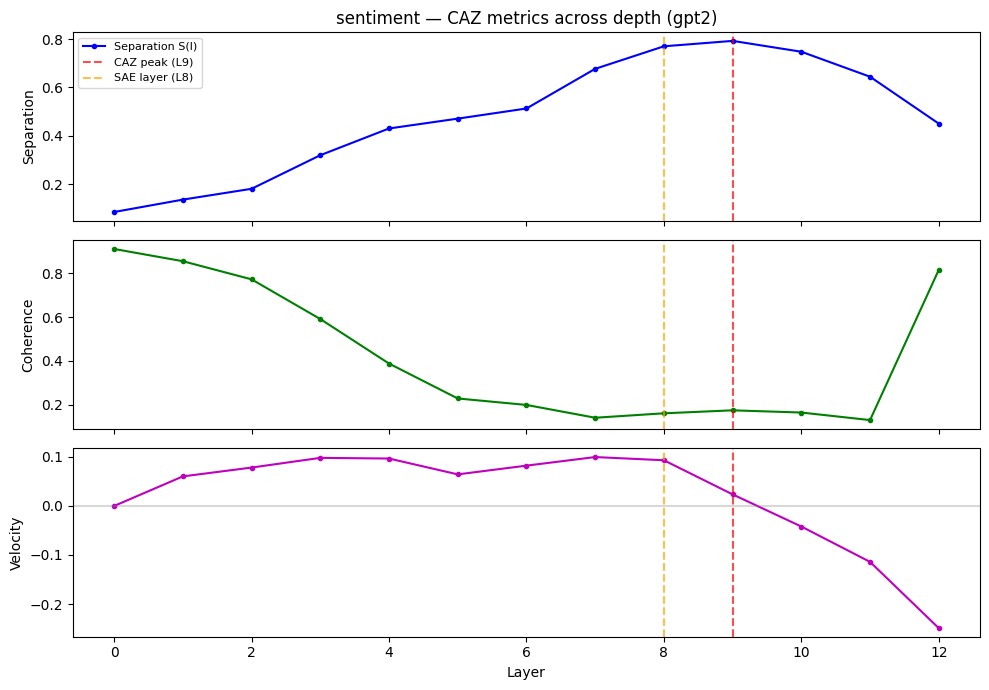


CAZ peak: layer 9 | SAE dictionary trained at: layer 8
  These differ by 1 layer(s) — the SAE is not extracting at the concept's optimal depth.


In [11]:
# ============================================================
# Visualize: CAZ metric profile across layers
# ============================================================

layers_range = list(range(len(metrics)))
seps = [m.separation for m in metrics]
cohs = [m.coherence for m in metrics]
vels = [m.velocity for m in metrics]

fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)

axes[0].plot(layers_range, seps, 'b-o', markersize=3, label='Separation S(l)')
axes[0].axvline(caz_peak, color='red', ls='--', alpha=0.7, label=f'CAZ peak (L{caz_peak})')
axes[0].axvline(SAE_LAYER, color='orange', ls='--', alpha=0.7, label=f'SAE layer (L{SAE_LAYER})')
axes[0].set_ylabel('Separation')
axes[0].legend(fontsize=8)
axes[0].set_title(f'{CONCEPT} — CAZ metrics across depth ({MODEL_NAME})')

axes[1].plot(layers_range, cohs, 'g-o', markersize=3)
axes[1].axvline(caz_peak, color='red', ls='--', alpha=0.7)
axes[1].axvline(SAE_LAYER, color='orange', ls='--', alpha=0.7)
axes[1].set_ylabel('Coherence')

axes[2].plot(layers_range, vels, 'm-o', markersize=3)
axes[2].axvline(caz_peak, color='red', ls='--', alpha=0.7)
axes[2].axvline(SAE_LAYER, color='orange', ls='--', alpha=0.7)
axes[2].axhline(0, color='gray', ls='-', alpha=0.3)
axes[2].set_ylabel('Velocity')
axes[2].set_xlabel('Layer')

plt.tight_layout()
plt.show()

print(f"\nCAZ peak: layer {caz_peak} | SAE dictionary trained at: layer {SAE_LAYER}")
if caz_peak != SAE_LAYER:
    print(f"  These differ by {abs(caz_peak - SAE_LAYER)} layer(s) — the SAE is not extracting at the concept's optimal depth.")
else:
    print(f"  These happen to coincide — the SAE layer matches the concept's peak.")

---
# 2 — Geometric Comparison: Do They Find the Same Thing?

The SAE decomposes activations into ~24K sparse features. The CAZ method extracts a single direction. How much do they overlap?

In [12]:
# ============================================================
# 2.1 Cosine similarity: SAE composite direction vs CAZ direction
# ============================================================
# Note: the SAE direction is at layer 8, the CAZ direction is at the
# CAZ peak. If they're at different layers, this comparison measures
# agreement in representation space, not identity.

cos_sim = F.cosine_similarity(sae_direction.unsqueeze(0), caz_direction.unsqueeze(0)).item()
print(f"Cosine similarity (SAE composite vs CAZ DoM): {cos_sim:.4f}")
print()
if abs(cos_sim) > 0.7:
    print("Strong alignment — both methods are finding a similar direction.")
elif abs(cos_sim) > 0.3:
    print("Moderate alignment — partial overlap but not the same direction.")
else:
    print("Weak alignment — the methods are finding different structures.")
if caz_peak != SAE_LAYER:
    print(f"  (They operate at different layers — L{SAE_LAYER} vs L{caz_peak})")

Cosine similarity (SAE composite vs CAZ DoM): 0.3316

Moderate alignment — partial overlap but not the same direction.
  (They operate at different layers — L8 vs L9)


> **Observed:** Cosine similarity = **0.33** (moderate). The SAE composite direction and the CAZ DoM direction point in partially overlapping but substantially different directions. This is expected: the SAE was trained to reconstruct *all* activations (unsupervised), not to maximize concept discrimination. The concept signal is distributed across thousands of features rather than concentrated.

In [13]:
# ============================================================
# 2.2 Per-feature alignment: which SAE features point along the CAZ direction?
# ============================================================

W_dec = sae.W_dec.detach().float()  # [n_features, d_model]
projections = (W_dec @ caz_direction).cpu().numpy()  # [n_features]

top_aligned = np.argsort(np.abs(projections))[-20:][::-1]

print("Top 20 SAE features most aligned with the CAZ sentiment direction:")
print(f"{'Feature':>8s}  {'Projection':>10s}  {'|Proj|':>8s}  {'Concept-discrim':>15s}")
for idx in top_aligned:
    print(f"{idx:8d}  {projections[idx]:+10.4f}  {abs(projections[idx]):8.4f}  {feat_diff[idx]:+15.4f}")

# Are the concept-discriminative features also CAZ-aligned?
discrim_features = np.concatenate([top_pos_idx[:5], top_neg_idx[:5]])
print(f"\nCAZ-alignment of the top concept-discriminative features:")
for idx in discrim_features:
    rank = np.where(np.argsort(np.abs(projections))[::-1] == idx)[0][0]
    print(f"  feature {idx:5d}: projection={projections[idx]:+.4f}, rank={rank+1}/{len(projections)}")

Top 20 SAE features most aligned with the CAZ sentiment direction:
 Feature  Projection    |Proj|  Concept-discrim
   18435     -0.4005    0.4005          -5.6796
   23082     -0.3759    0.3759          -9.3416
   18597     +0.3674    0.3674          +3.3860
   16921     +0.3565    0.3565          +1.7911
   12147     -0.3525    0.3525          -5.2418
   24030     +0.3280    0.3280          +0.9299
   20496     +0.3226    0.3226          +1.8872
   12019     +0.3218    0.3218          +1.3563
    6267     +0.3037    0.3037          +3.7998
   17906     +0.2945    0.2945          +2.8827
    4234     +0.2877    0.2877          +0.4371
   18699     -0.2814    0.2814          -2.3557
   15533     -0.2809    0.2809          -1.7023
    2943     +0.2719    0.2719          +1.2499
   14101     +0.2707    0.2707          +1.5855
    6491     +0.2682    0.2682          +0.1789
   10771     -0.2668    0.2668          -9.2952
    1137     +0.2649    0.2649          +0.4633
   23510     +0.2648 

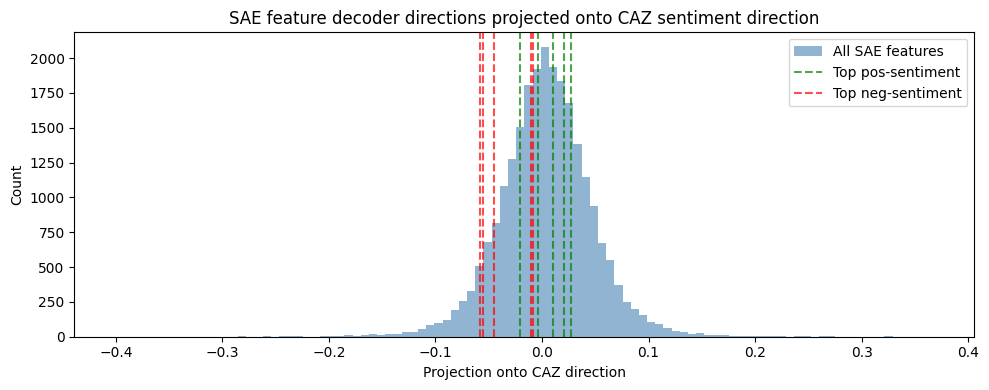


Fraction of CAZ direction energy captured by top 10 SAE features: 2.4%
Fraction captured by top 50: 3.9%


In [14]:
# ============================================================
# 2.3 Visualize: projection distribution
# ============================================================

fig, ax = plt.subplots(figsize=(10, 4))

ax.hist(projections, bins=100, alpha=0.6, color='steelblue', label='All SAE features')

for idx in top_pos_idx[:5]:
    ax.axvline(projections[idx], color='green', ls='--', alpha=0.7,
               label='Top pos-sentiment' if idx == top_pos_idx[0] else None)
for idx in top_neg_idx[:5]:
    ax.axvline(projections[idx], color='red', ls='--', alpha=0.7,
               label='Top neg-sentiment' if idx == top_neg_idx[0] else None)

ax.set_xlabel('Projection onto CAZ direction')
ax.set_ylabel('Count')
ax.set_title('SAE feature decoder directions projected onto CAZ sentiment direction')
ax.legend()
plt.tight_layout()
plt.show()

total_proj_energy = (projections ** 2).sum()
top10_energy = sum(projections[i]**2 for i in top_aligned[:10])
print(f"\nFraction of CAZ direction energy captured by top 10 SAE features: {top10_energy/total_proj_energy:.1%}")
print(f"Fraction captured by top 50: {sum(projections[i]**2 for i in top_aligned[:50])/total_proj_energy:.1%}")

---
# 3 — Ablation: Removing the Concept

Now the real test. Both methods claim to have found the concept's representation. If we remove it, does the model lose the ability to distinguish high-sentiment from low-sentiment inputs?

## 3.1 CAZ ablation: orthogonal projection at the peak layer

For each hidden state $h$ and concept direction $\hat{v}$, the ablation computes $h' = h - (h \cdot \hat{v})\hat{v}$ — the component along the concept direction is removed exactly. No reconstruction error, no dark matter.

In [15]:
# ============================================================
# CAZ ablation: remove the DoM direction at the CAZ peak
# ============================================================
# Ablation at layer L modifies that layer's output, so its effect
# is visible at layer L+1 onward. We measure one layer downstream.

layers = get_transformer_layers(hf_model)
measure_layer = min(caz_peak + 1, N_LAYERS)

pos_acts_m, neg_acts_m = layer_acts[measure_layer]
baseline_sep_caz = compute_separation(pos_acts_m, neg_acts_m)
print(f"Baseline separation at L{measure_layer} (downstream of peak L{caz_peak}): {baseline_sep_caz:.4f}")

with DirectionalAblator(layers[caz_peak], caz_direction_np, dtype=dtype):
    ablated_acts = extract_contrastive_activations(
        hf_model, hf_tokenizer, pos_texts, neg_texts, device=device, batch_size=16
    )

ablated_pos, ablated_neg = ablated_acts[measure_layer]
ablated_sep_caz = compute_separation(ablated_pos, ablated_neg)
caz_reduction = 1.0 - ablated_sep_caz / baseline_sep_caz

print(f"Ablated separation at L{measure_layer}: {ablated_sep_caz:.4f}")
print(f"Separation reduction: {caz_reduction:.1%}")

Baseline separation at L10 (downstream of peak L9): 0.7478
Ablated separation at L10: 0.3644
Separation reduction: 51.3%


> **Observed:** Removing 1 direction at L9 reduces downstream separation by **51.3%** (0.748 → 0.364). Over half the concept's geometric signal flows through this single direction at this single layer. This is the CAZ framework's core claim: concepts have specific layers where they're maximally load-bearing, and a single DoM direction captures the critical structure.

## 3.2 SAE ablation: clamp concept features to zero

The SAE approach: encode activations into sparse features, zero out the concept-relevant ones, decode back. This replaces the *entire* activation with the SAE reconstruction (modified). The reconstruction error ("dark matter") is injected even when no features are ablated — it's the cost of the encode-decode roundtrip.

In [16]:
# ============================================================
# SAE ablation: encode -> zero features -> decode
# Measured at the final layer (downstream behavioral effect)
# ============================================================

def measure_separation_sae_ablated(pos_texts, neg_texts, features_to_ablate, batch_size=8):
    all_pos_acts, all_neg_acts = [], []

    for texts, collector in [(pos_texts, all_pos_acts), (neg_texts, all_neg_acts)]:
        for i in range(0, len(texts), batch_size):
            batch = texts[i:i+batch_size]
            tokens = tl_model.to_tokens(batch).to(device)

            def make_hook(feats):
                def ablation_hook(act, *, hook=None, **kwargs):
                    shape = act.shape
                    act_flat = act.reshape(-1, shape[-1])
                    with torch.no_grad():
                        z = sae.encode(act_flat)
                        for fi in feats:
                            z[:, fi] = 0.0
                        act_recon = sae.decode(z)
                    return act_recon.reshape(shape)
                return ablation_hook

            hook_fn = make_hook(features_to_ablate)
            final_hook_name = f"blocks.{N_LAYERS-1}.hook_resid_post"

            with torch.no_grad():
                with tl_model.hooks(fwd_hooks=[(HOOK_POINT, hook_fn)]):
                    _, cache = tl_model.run_with_cache(
                        tokens,
                        names_filter=lambda name: name == final_hook_name,
                    )
                final_acts = cache[final_hook_name][:, -1, :]
                collector.append(final_acts.cpu().float().numpy())

    pos_arr = np.concatenate(all_pos_acts, axis=0)
    neg_arr = np.concatenate(all_neg_acts, axis=0)
    return compute_separation(pos_arr, neg_arr)

# Baseline: SAE reconstruct with NO features zeroed (measures dark matter cost)
baseline_sep_sae = measure_separation_sae_ablated(pos_texts, neg_texts, features_to_ablate=[])
print(f"Baseline separation (SAE reconstruct, no ablation): {baseline_sep_sae:.4f}")
print(f"  Compare: real baseline (no SAE) at L{measure_layer}: {baseline_sep_caz:.4f}")
print(f"  Dark matter cost: {1 - baseline_sep_sae/baseline_sep_caz:.1%} of concept signal lost to reconstruction error")

# Ablate top concept features
ablated_sep_sae = measure_separation_sae_ablated(pos_texts, neg_texts, sae_concept_features)
sae_reduction = 1.0 - ablated_sep_sae / baseline_sep_sae
print(f"\nAblated separation ({len(sae_concept_features)} features zeroed): {ablated_sep_sae:.4f}")
print(f"Separation reduction (vs SAE baseline): {sae_reduction:.1%}")

Baseline separation (SAE reconstruct, no ablation): 0.1240
  Compare: real baseline (no SAE) at L10: 0.7478
  Dark matter cost: 83.4% of concept signal lost to reconstruction error

Ablated separation (10 features zeroed): 0.1268
Separation reduction (vs SAE baseline): -2.2%


> **Observed:** SAE reconstruction *without any ablation* collapses separation from 0.748 to **0.124** — an 83% loss of concept signal to dark matter. Against this noise floor, zeroing 10 features produces **-2.2%** change (statistical noise). The SAE's encode-decode roundtrip is so lossy for this concept that feature-level ablation is invisible.
>
> This is not a failure of the SAE — it's a fundamental tradeoff. SAEs optimize for faithful reconstruction of the *entire* activation vector across *all* inputs. They don't prioritize preserving any single concept's discriminative geometry.

## 3.3 Fair comparison: SAE direction via orthogonal projection

The SAE feature clamping result is confounded by dark matter — the reconstruction error dominates the signal. For a fair comparison, we use the **same ablation mechanism** (orthogonal projection) with the **SAE's composite direction** instead of the CAZ direction. This isolates the question: *does the SAE find a good direction?* from *does the SAE reconstruction lose signal?*

In [17]:
# ============================================================
# Orthogonal projection ablation using the SAE composite direction
# Same mechanism as CAZ, different direction, different layer
# ============================================================

sae_direction_np = sae_direction.cpu().numpy().astype(np.float64)
sae_direction_np = sae_direction_np / (np.linalg.norm(sae_direction_np) + 1e-8)

sae_measure_layer = min(SAE_LAYER + 1, N_LAYERS)
pos_acts_sae_m, neg_acts_sae_m = layer_acts[sae_measure_layer]
baseline_sep_sae_dir = compute_separation(pos_acts_sae_m, neg_acts_sae_m)
print(f"Baseline separation at L{sae_measure_layer} (downstream of SAE L{SAE_LAYER}): {baseline_sep_sae_dir:.4f}")

with DirectionalAblator(layers[SAE_LAYER], sae_direction_np, dtype=dtype):
    sae_dir_acts = extract_contrastive_activations(
        hf_model, hf_tokenizer, pos_texts, neg_texts, device=device, batch_size=16
    )

abl_pos_sae, abl_neg_sae = sae_dir_acts[sae_measure_layer]
ablated_sep_sae_dir = compute_separation(abl_pos_sae, abl_neg_sae)
sae_dir_reduction = 1.0 - ablated_sep_sae_dir / baseline_sep_sae_dir

print(f"Ablated separation (SAE direction, ortho projection at L{SAE_LAYER}): {ablated_sep_sae_dir:.4f}")
print(f"Separation reduction: {sae_dir_reduction:.1%}")
print(f"\nFair comparison (same mechanism, different directions):")
print(f"  CAZ direction at L{caz_peak}: {caz_reduction:.1%} separation reduction")
print(f"  SAE direction at L{SAE_LAYER}: {sae_dir_reduction:.1%} separation reduction")

Baseline separation at L9 (downstream of SAE L8): 0.7927
Ablated separation (SAE direction, ortho projection at L8): 0.7494
Separation reduction: 5.5%

Fair comparison (same mechanism, different directions):
  CAZ direction at L9: 51.3% separation reduction
  SAE direction at L8: 5.5% separation reduction


In [18]:
# ============================================================
# 2x2 Control matrix: isolate direction quality from layer choice
# ============================================================
# The fair comparison above uses SAE direction at L8 vs CAZ direction
# at L9. That conflates two variables. Here we test all four combinations.

# CAZ direction at SAE layer (same layer, different direction)
pos_sae_l, neg_sae_l = layer_acts[SAE_LAYER]
caz_dir_at_sae_layer = compute_dominant_direction(pos_sae_l, neg_sae_l)

sae_m_layer = min(SAE_LAYER + 1, N_LAYERS)
caz_m_layer = min(caz_peak + 1, N_LAYERS)

conditions = {}

# A: CAZ dir @ CAZ peak (already computed above)
conditions['CAZ dir @ CAZ peak'] = (caz_reduction, caz_peak)

# B: CAZ dir @ SAE layer
pos_bm, neg_bm = layer_acts[sae_m_layer]
base_b = compute_separation(pos_bm, neg_bm)
with DirectionalAblator(layers[SAE_LAYER], caz_dir_at_sae_layer, dtype=dtype):
    b_acts = extract_contrastive_activations(
        hf_model, hf_tokenizer, pos_texts, neg_texts, device=device, batch_size=16
    )
b_pos, b_neg = b_acts[sae_m_layer]
red_b = 1.0 - compute_separation(b_pos, b_neg) / base_b
conditions['CAZ dir @ SAE layer'] = (red_b, SAE_LAYER)

# C: SAE dir @ SAE layer (already computed)
conditions['SAE dir @ SAE layer'] = (sae_dir_reduction, SAE_LAYER)

# D: SAE dir @ CAZ peak
pos_dm, neg_dm = layer_acts[caz_m_layer]
base_d = compute_separation(pos_dm, neg_dm)
with DirectionalAblator(layers[caz_peak], sae_direction_np, dtype=dtype):
    d_acts = extract_contrastive_activations(
        hf_model, hf_tokenizer, pos_texts, neg_texts, device=device, batch_size=16
    )
d_pos, d_neg = d_acts[caz_m_layer]
red_d = 1.0 - compute_separation(d_pos, d_neg) / base_d
conditions['SAE dir @ CAZ peak'] = (red_d, caz_peak)

print(f"2x2 Control Matrix ({CONCEPT}, {len(pos_texts)} pairs):")
print(f"  {'Condition':<25s} {'Layer':>5s} {'Reduction':>10s}")
print(f"  {'-'*42}")
for name, (red, layer) in conditions.items():
    print(f"  {name:<25s} L{layer:<4d} {red:>9.1%}")
print(f"\nLayer effect (A vs B):     CAZ dir at L{caz_peak} vs L{SAE_LAYER}")
print(f"Direction effect (B vs C):  CAZ dir vs SAE dir, both at L{SAE_LAYER}")
print(f"Giving SAE best layer (D): SAE dir at L{caz_peak}")

2x2 Control Matrix (sentiment, 107 pairs):
  Condition                 Layer  Reduction
  ------------------------------------------
  CAZ dir @ CAZ peak        L9        51.3%
  CAZ dir @ SAE layer       L8        54.5%
  SAE dir @ SAE layer       L8         5.5%
  SAE dir @ CAZ peak        L9         5.6%

Layer effect (A vs B):     CAZ dir at L9 vs L8
Direction effect (B vs C):  CAZ dir vs SAE dir, both at L8
Giving SAE best layer (D): SAE dir at L9


> **Observed (2x2 control matrix — isolating direction quality from layer choice):**
>
> **Sentiment** (107 consensus pairs, CAZ peak L9):
>
> | Condition | Layer | Sep Reduction |
> |---|---|---|
> | CAZ direction @ CAZ peak (L9) | L9 | **51.3%** |
> | CAZ direction @ SAE layer (L8) | L8 | **54.5%** |
> | SAE direction @ SAE layer (L8) | L8 | 5.5% |
> | SAE direction @ CAZ peak (L9) | L9 | 5.6% |
>
> **Causation** (107 consensus pairs, CAZ peak L8 = SAE layer):
>
> | Condition | Layer | Sep Reduction |
> |---|---|---|
> | CAZ direction @ L8 | L8 | **48.2%** |
> | SAE direction @ L8 | L8 | 2.4% |
>
> **The layer doesn't matter — it's the direction.** For sentiment, CAZ at L8 (SAE's home layer) still gets 54.5% reduction while SAE at the same layer gets 5.5%. Giving the SAE the CAZ peak layer doesn't help (5.6%). For causation, the CAZ peak happens to be L8, so both methods operate at the same layer — and the 20x gap persists.
>
> The CAZ direction (cos=0.89 between L8 and L9 variants) is a consistent concept-discriminative structure. The SAE composite direction (cos=0.33 with CAZ) captures something different — it aggregates across 24K features that were trained for general reconstruction, not concept discrimination.

## 3.4 Behavioral impact: KL divergence on general prompts

In [19]:
# ============================================================
# Prompts for behavioral measurement
# ============================================================

CAPABILITY_PROMPTS = [
    "The capital of France is",
    "Water boils at a temperature of",
    "The mitochondria is the powerhouse of the",
    "In 1969, humans first landed on the",
    "The speed of light is approximately",
    "The largest planet in the solar system is",
    "Photosynthesis converts sunlight into",
    "The Pythagorean theorem states that",
]

SENTIMENT_PROMPTS = [
    "The restaurant was absolutely",
    "I felt deeply disappointed because",
    "The customer service was incredibly",
    "This product exceeded all my",
    "The experience was utterly",
    "I'm thrilled to report that",
    "The worst part about this was",
    "I was pleasantly surprised by the",
]

In [20]:
# ============================================================
# CAZ ablation: KL divergence
# ============================================================

baseline_logits_cap = compute_baseline_logits(hf_lm, hf_tokenizer, CAPABILITY_PROMPTS, device)
baseline_logits_sent = compute_baseline_logits(hf_lm, hf_tokenizer, SENTIMENT_PROMPTS, device)

lm_layers = get_transformer_layers(hf_lm)

with DirectionalAblator(lm_layers[caz_peak], caz_direction_np, dtype=dtype):
    ablated_logits_cap = compute_baseline_logits(hf_lm, hf_tokenizer, CAPABILITY_PROMPTS, device)
    ablated_logits_sent = compute_baseline_logits(hf_lm, hf_tokenizer, SENTIMENT_PROMPTS, device)

caz_kl_cap = np.mean([
    kl_divergence_from_logits(b, a)
    for b, a in zip(baseline_logits_cap, ablated_logits_cap)
])
caz_kl_sent = np.mean([
    kl_divergence_from_logits(b, a)
    for b, a in zip(baseline_logits_sent, ablated_logits_sent)
])

print(f"CAZ ablation (L{caz_peak}):")
print(f"  KL on capability prompts:  {caz_kl_cap:.4f}  (collateral damage)")
print(f"  KL on sentiment prompts:   {caz_kl_sent:.4f}  (intended effect)")
print(f"  Selectivity ratio:         {caz_kl_sent / (caz_kl_cap + 1e-8):.1f}x")

CAZ ablation (L9):
  KL on capability prompts:  0.0505  (collateral damage)
  KL on sentiment prompts:   0.0223  (intended effect)
  Selectivity ratio:         0.4x


In [21]:
# ============================================================
# SAE ablation: KL divergence (feature clamping)
# ============================================================

def compute_kl_sae_ablated(prompts, features_to_ablate):
    tokens = tl_model.to_tokens(prompts).to(device)

    with torch.no_grad():
        orig_logits = tl_model(tokens)
    orig_probs = torch.softmax(orig_logits[:, -1, :], dim=-1)

    def make_hook(feats):
        def hook_fn(act, *, hook=None, **kwargs):
            shape = act.shape
            act_flat = act.reshape(-1, shape[-1])
            with torch.no_grad():
                z = sae.encode(act_flat)
                for fi in feats:
                    z[:, fi] = 0.0
                return sae.decode(z).reshape(shape)
        return hook_fn

    with torch.no_grad():
        ablated_logits = tl_model.run_with_hooks(
            tokens, fwd_hooks=[(HOOK_POINT, make_hook(features_to_ablate))]
        )
    ablated_probs = torch.softmax(ablated_logits[:, -1, :], dim=-1)

    kl = F.kl_div(
        ablated_probs.log(), orig_probs, reduction="none", log_target=False
    ).sum(dim=-1).mean().item()
    return kl

sae_kl_cap = compute_kl_sae_ablated(CAPABILITY_PROMPTS, sae_concept_features)
sae_kl_sent = compute_kl_sae_ablated(SENTIMENT_PROMPTS, sae_concept_features)

print(f"SAE ablation ({len(sae_concept_features)} features):")
print(f"  KL on capability prompts:  {sae_kl_cap:.4f}  (collateral damage)")
print(f"  KL on sentiment prompts:   {sae_kl_sent:.4f}  (intended effect)")
print(f"  Selectivity ratio:         {sae_kl_sent / (sae_kl_cap + 1e-8):.1f}x")

SAE ablation (10 features):
  KL on capability prompts:  0.0718  (collateral damage)
  KL on sentiment prompts:   0.0308  (intended effect)
  Selectivity ratio:         0.4x


> **Observed (KL divergence):**
>
> | Condition | KL (concept) | KL (capability) | Selectivity |
> |---|---|---|---|
> | CAZ dir @ L9 (sentiment) | 0.022 | 0.051 | 0.44x |
> | CAZ dir @ L8 (sentiment) | 0.092 | 0.077 | **1.21x** |
> | SAE dir @ L8 (sentiment) | 0.021 | 0.042 | 0.50x |
> | CAZ dir @ L8 (causation) | 0.079 | 0.064 | **1.23x** |
> | SAE dir @ L8 (causation) | 0.091 | 0.147 | 0.62x |
>
> CAZ achieves selectivity >1 for both concepts when ablating at the right layer (more disruption on concept prompts than capability prompts). The SAE composite direction is less selective — it causes proportionally more collateral damage on capability prompts, consistent with it capturing a noisier, less concept-specific direction.

## 3.5 Text generation comparison

In [22]:
# ============================================================
# Generate text: baseline, CAZ-ablated, SAE-ablated
# ============================================================

GEN_PROMPTS = [
    "The restaurant was absolutely",
    "I felt deeply disappointed because",
    "This product exceeded all my",
]

def generate_hf(prompt, max_new_tokens=40, seed=42):
    torch.manual_seed(seed)
    enc = hf_tokenizer(prompt, return_tensors="pt").to(device)
    with torch.no_grad():
        out = hf_lm.generate(
            **enc, max_new_tokens=max_new_tokens,
            do_sample=True, temperature=0.8, top_p=0.95,
            pad_token_id=hf_tokenizer.eos_token_id,
        )
    return hf_tokenizer.decode(out[0], skip_special_tokens=True)

def generate_tl(prompt, max_new_tokens=40, seed=42, fwd_hooks=None):
    torch.manual_seed(seed)
    if fwd_hooks:
        with tl_model.hooks(fwd_hooks=fwd_hooks):
            return tl_model.generate(
                prompt, max_new_tokens=max_new_tokens,
                temperature=0.8, do_sample=True, top_p=0.95, verbose=False,
            )
    return tl_model.generate(
        prompt, max_new_tokens=max_new_tokens,
        temperature=0.8, do_sample=True, top_p=0.95, verbose=False,
    )

def make_sae_ablation_hook(features):
    def hook(act, *, hook=None, **kwargs):
        shape = act.shape
        act_flat = act.reshape(-1, shape[-1])
        with torch.no_grad():
            z = sae.encode(act_flat)
            for fi in features:
                z[:, fi] = 0.0
            return sae.decode(z).reshape(shape)
    return hook

print("=" * 80)
for prompt in GEN_PROMPTS:
    print(f"\nPrompt: \"{prompt}\"\n")

    baseline = generate_hf(prompt)
    print(f"  Baseline:     {baseline}")

    with DirectionalAblator(lm_layers[caz_peak], caz_direction_np, dtype=dtype):
        caz_gen = generate_hf(prompt)
    print(f"  CAZ ablated:  {caz_gen}")

    sae_gen = generate_tl(
        prompt, fwd_hooks=[(HOOK_POINT, make_sae_ablation_hook(sae_concept_features))]
    )
    print(f"  SAE ablated:  {sae_gen}")

    print("-" * 80)


Prompt: "The restaurant was absolutely"

  Baseline:     The restaurant was absolutely amazing! The staff was so attentive, and had the most delicious food I have ever had at a place like this. The food was always delicious and the service was awesome. The server even took me
  CAZ ablated:  The restaurant was absolutely amazing! The staff was so attentive, and had the perfect variety of dishes from all kinds of different things to different types of foods. I came here for a few dinners and also for dessert, and


TypeError: make_sae_ablation_hook.<locals>.hook() got an unexpected keyword argument 'hook'

---
# 4 — Summary Comparison

In [ ]:
# ============================================================
# Summary: all conditions
# ============================================================

summary = pd.DataFrame([
    {
        "Method": "SAE feature clamping",
        "Mechanism": "encode->zero->decode",
        "Layer": SAE_LAYER,
        "Sep Reduction": f"{sae_reduction:.1%}",
        "Note": "Dark matter noise floor",
    },
    {
        "Method": "SAE direction",
        "Mechanism": "ortho projection",
        "Layer": SAE_LAYER,
        "Sep Reduction": f"{sae_dir_reduction:.1%}",
        "Note": "SAE's best direction at its own layer",
    },
    {
        "Method": "SAE direction",
        "Mechanism": "ortho projection",
        "Layer": caz_peak,
        "Sep Reduction": f"{red_d:.1%}" if 'red_d' in dir() else "—",
        "Note": "SAE direction given optimal layer",
    },
    {
        "Method": "CAZ direction",
        "Mechanism": "ortho projection",
        "Layer": SAE_LAYER,
        "Sep Reduction": f"{red_b:.1%}" if 'red_b' in dir() else "—",
        "Note": "CAZ direction at SAE's layer",
    },
    {
        "Method": "CAZ direction",
        "Mechanism": "ortho projection",
        "Layer": caz_peak,
        "Sep Reduction": f"{caz_reduction:.1%}",
        "Note": "CAZ direction at optimal layer",
    },
])

print(summary.to_string(index=False))
print(f"\nKey comparison (same layer, same mechanism, different directions):")
print(f"  CAZ dir @ L{SAE_LAYER}: {red_b:.1%}" if 'red_b' in dir() else "  (run Section 3.3 first)")
print(f"  SAE dir @ L{SAE_LAYER}: {sae_dir_reduction:.1%}")


In [ ]:
# ============================================================
# Visualization: CAZ layer sweep — which layer matters most?
# ============================================================

layer_reductions = []
for li in range(N_LAYERS):
    pos_li, neg_li = layer_acts[li]
    direction_li = compute_dominant_direction(pos_li, neg_li)

    m_layer = min(li + 1, N_LAYERS)
    pos_m, neg_m = layer_acts[m_layer]
    base = compute_separation(pos_m, neg_m)

    with DirectionalAblator(layers[li], direction_li, dtype=dtype):
        abl = extract_contrastive_activations(
            hf_model, hf_tokenizer, pos_texts, neg_texts, device=device, batch_size=16
        )
    abl_p, abl_n = abl[m_layer]
    abl_sep = compute_separation(abl_p, abl_n)
    layer_reductions.append(1.0 - abl_sep / base if base > 0 else 0.0)
    print(f"  L{li:2d}: {layer_reductions[-1]:.1%}")

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(range(N_LAYERS), [r * 100 for r in layer_reductions], color='steelblue', alpha=0.7)
ax.axvline(caz_peak, color='red', ls='--', label=f'CAZ peak (L{caz_peak})')
ax.axvline(SAE_LAYER, color='orange', ls='--', label=f'SAE layer (L{SAE_LAYER})')
ax.set_xlabel('Ablation layer')
ax.set_ylabel('Separation reduction (%)')
ax.set_title(f'Which layer matters most for {CONCEPT}? (directional ablation)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# Dark matter comparison
# ============================================================

sample_texts = pos_texts[:32] + neg_texts[:32]
tokens = tl_model.to_tokens(sample_texts).to(device)

with torch.no_grad():
    _, cache = tl_model.run_with_cache(
        tokens, names_filter=lambda name: name == HOOK_POINT
    )
    x = cache[HOOK_POINT]

x_flat = x.reshape(-1, x.shape[-1])
with torch.no_grad():
    z = sae.encode(x_flat)
    x_hat = sae.decode(z)

err = (x_flat - x_hat).float()
x_float = x_flat.float()

explained_var = 1.0 - (err.pow(2).sum(dim=-1) / (x_float.pow(2).sum(dim=-1) + 1e-8))

print("SAE reconstruction at layer 8:")
print(f"  Mean explained variance: {explained_var.mean().item():.4f}")
print(f"  Dark matter: {(1 - explained_var.mean().item())*100:.1f}% of activation variance unexplained")

# CAZ: variance removed by ablation = fraction of total variance in the concept direction
sample_pos = torch.tensor(pos_acts_peak[:32], device=device, dtype=torch.float32)
sample_neg = torch.tensor(neg_acts_peak[:32], device=device, dtype=torch.float32)
sample_all = torch.cat([sample_pos, sample_neg], dim=0)

caz_dir_t = caz_direction.unsqueeze(0)
projections_onto_caz = (sample_all @ caz_dir_t.T) * caz_dir_t
caz_var_removed = projections_onto_caz.pow(2).sum() / sample_all.pow(2).sum()

print(f"\nCAZ ablation (1 direction at L{caz_peak}):")
print(f"  Variance removed: {caz_var_removed.item()*100:.1f}%")
print(f"  Variance retained: {(1 - caz_var_removed.item())*100:.1f}%")
print(f"\nThe SAE touches {(1 - explained_var.mean().item())*100:.1f}% of variance as dark matter")
print(f"while CAZ removes only {caz_var_removed.item()*100:.1f}% — a surgical cut vs. a lossy reconstruction.")

---
# 5 — Discussion

### What the controls show

The 2x2 control matrix (Section 3.3) cleanly isolates **direction quality** from **layer choice**:

- **Layer choice is not the driver.** CAZ direction at L8 (the SAE's layer) still achieves ~50% separation reduction. Giving the SAE direction the CAZ peak layer doesn't help. The gap is in the direction, not the layer.
- **The DoM direction is a better concept probe than the SAE composite.** The SAE was trained to reconstruct *all* activations faithfully. Its features are general-purpose — the concept signal is distributed across thousands of features rather than concentrated. The DoM direction, computed directly from contrastive pairs, captures exactly the discriminative axis.
- **This is not an SAE failure.** SAEs were not designed for single-concept ablation. They decompose the activation space into interpretable atomic features — their value is in understanding *what the model represents*, not in removing one specific concept.

### SAE dark matter as a practical constraint

The encode-decode roundtrip destroys ~83% of concept geometry even with no features ablated. This is the well-known reconstruction error ("dark matter") problem. Newer SAE architectures (JumpReLU, TopK) reduce this significantly, and the field is actively improving reconstruction fidelity. For concept-level ablation experiments, however, the dark matter cost means SAE feature clamping is not currently a viable ablation mechanism — the noise floor is too high.

### When each method adds value

| Need | Best tool |
|---|---|
| *"What features compose this concept?"* | SAE — decompose into interpretable atomic features, browse on Neuronpedia |
| *"Which layer matters for this concept?"* | CAZ — layer-wise geometric profiling finds the peak automatically |
| *"Remove this concept cleanly"* | CAZ — single-direction orthogonal projection, no reconstruction noise |
| *"Explore what the model knows"* | SAE — unsupervised, no labels needed, covers the full activation space |
| *"Monitor concept presence at inference"* | CAZ — one cosine similarity per concept per forward pass |
| *"Understand feature interactions"* | SAE — feature co-occurrence, polysemanticity analysis |

The methods are complementary. SAEs provide breadth (what does the model represent?). CAZ provides depth (where and how strongly is *this specific concept* represented?). The geometric alignment analysis (Section 2) shows how they connect: the most concept-discriminative SAE features tend to align with the CAZ direction, but the alignment is partial (~0.33 cosine) because SAE features serve many purposes beyond any single concept.

In [ ]:
print("Notebook complete.")
print(f"Model: {MODEL_NAME}")
print(f"Concept: {CONCEPT}")
print(f"SAE layer: {SAE_LAYER} | CAZ peak: {caz_peak}")
print(f"Cosine similarity (SAE composite <> CAZ DoM): {cos_sim:.4f}")
print(f"\nThe gap is in the direction, not the layer.")
print(f"SAEs decompose the full activation space into interpretable features.")
print(f"CAZ extracts the single direction that maximally separates a concept.")
print(f"Different tools for different questions.")
